In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chisquare
from statsmodels.stats.proportion import proportions_ztest

In [3]:
road = "C:/Users/Karina/Downloads/ab_test_task_historical_data.csv"
df_hist = pd.read_csv(road)
road1 = "C:/Users/Karina/Downloads/ab_test_task_data.csv"
df_test = pd.read_csv(road1)

In [4]:
df_hist.head()

,id_user,date_reg,date_first_payment,date_spent_15_credits
0,1,2023-03-01 00:00:09.068945 UTC,2023-03-01 02:06:31.472018 UTC,2023-03-01 02:00:38.000000 UTC
1,2,2023-03-01 00:00:25.615471 UTC,NaN,2023-03-01 00:17:38.000000 UTC
2,3,2023-03-01 00:00:39.084989 UTC,2023-03-01 00:52:37.812217 UTC,2023-03-01 00:18:53.000000 UTC
3,4,2023-03-01 00:00:42.779311 UTC,NaN,NaN
4,5,2023-03-01 00:00:42.872660 UTC,NaN,NaN


In [5]:
df_hist.info()

<class 'pandas.DataFrame'>
RangeIndex: 59758 entries, 0 to 59757
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   id_user                59758 non-null  int64
 1   date_reg               59758 non-null  str  
 2   date_first_payment     3257 non-null   str  
 3   date_spent_15_credits  22268 non-null  str  
dtypes: int64(1), str(3)
memory usage: 1.8 MB


In [6]:
df_hist['date_reg'] = pd.to_datetime(df_hist['date_reg'])
df_hist['date_first_payment'] = pd.to_datetime(df_hist['date_first_payment'])
df_hist['date_spent_15_credits'] = pd.to_datetime(df_hist['date_spent_15_credits'])

In [7]:
df_hist.info()

<class 'pandas.DataFrame'>
RangeIndex: 59758 entries, 0 to 59757
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   id_user                59758 non-null  int64              
 1   date_reg               59758 non-null  datetime64[us, UTC]
 2   date_first_payment     3257 non-null   datetime64[us, UTC]
 3   date_spent_15_credits  22268 non-null  datetime64[us, UTC]
dtypes: datetime64[us, UTC](3), int64(1)
memory usage: 1.8 MB


In [10]:
# Визначення вікна реєстрацій 
days_total = df_hist['date_reg'].dt.date.nunique()

# Фільтрація цільової аудиторії
# Умова 1: Користувач витратив 15 кредитів
mask_reached_15 = df_hist['date_spent_15_credits'].notna()

# Умова 2: Користувач зробив оплату ДО того, як витратив 15 кредитів 
mask_paid_before = mask_reached_15 & (df_hist['date_first_payment'] < df_hist['date_spent_15_credits'])

# Відбираємо цільову аудиторію: ті, хто досяг 15 кредитів, МІНУС ті, хто заплатив раніше
df_true_target = df_hist[mask_reached_15 & ~mask_paid_before].copy()

# Розрахунок Baseline CR
baseline_cr = df_true_target['date_first_payment'].notna().mean()

# Розрахунок щоденного трафіку
daily_traffic = len(df_true_target) / days_total

# Вивід результатів
print(f"Вікно реєстрацій: {days_total} днів")
print(f"Розмір цільової аудиторії: {len(df_true_target)} користувачів")
print(f"Baseline CR: {baseline_cr:.4f} (або {baseline_cr * 100:.2f}%)")
print(f"Середній денний трафік: {daily_traffic:.0f} користувачів на день")

Вікно реєстрацій: 9 днів
Розмір цільової аудиторії: 21832 користувачів
Baseline CR: 0.1267 (або 12.67%)
Середній денний трафік: 2426 користувачів на день


In [11]:
df_test.head()

,id_user,date_reg,date_first_payment,date_spent_15_credits,date_reminder,match
0,1,2023-03-14 08:37:01.855460 UTC,2023-03-14 11:25:23.962741 UTC,2023-03-14 09:15:31.000000 UTC,2023-03-14 09:04:03.823970 UTC,1
1,2,2023-03-14 08:37:20.988023 UTC,NaN,NaN,NaN,0
2,3,2023-03-14 08:39:01.389639 UTC,NaN,2023-03-14 08:53:21.000000 UTC,2023-03-14 08:46:43.971330 UTC,0
3,4,2023-03-14 08:39:18.222582 UTC,NaN,NaN,2023-03-14 09:18:04.290338 UTC,0
4,5,2023-03-14 08:40:40.216560 UTC,NaN,NaN,NaN,1


In [12]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 125217 entries, 0 to 125216
Data columns (total 6 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   id_user                125217 non-null  int64
 1   date_reg               125217 non-null  str  
 2   date_first_payment     7237 non-null    str  
 3   date_spent_15_credits  51553 non-null   str  
 4   date_reminder          15208 non-null   str  
 5   match                  125217 non-null  int64
dtypes: int64(2), str(4)
memory usage: 5.7 MB


In [13]:
date_columns = ['date_reg', 'date_first_payment', 'date_spent_15_credits', 'date_reminder']
for col in date_columns:
    df_test[col] = pd.to_datetime(df_test[col])

In [14]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 125217 entries, 0 to 125216
Data columns (total 6 columns):
 #   Column                 Non-Null Count   Dtype              
---  ------                 --------------   -----              
 0   id_user                125217 non-null  int64              
 1   date_reg               125217 non-null  datetime64[us, UTC]
 2   date_first_payment     7237 non-null    datetime64[us, UTC]
 3   date_spent_15_credits  51553 non-null   datetime64[us, UTC]
 4   date_reminder          15208 non-null   datetime64[us, UTC]
 5   match                  125217 non-null  int64              
dtypes: datetime64[us, UTC](4), int64(2)
memory usage: 5.7 MB


In [15]:
# Перевірка SRM на всьому трафіку
users_total = len(df_test)
users_group_0 = len(df_test[df_test['match'] == 0])
users_group_1 = len(df_test[df_test['match'] == 1])

In [18]:
# Використовуємо хі-квадрат для перевірки відхилення від очікуваного розподілу 50/50
chi_stat, p_value_srm = chisquare(
    f_obs=[users_group_0, users_group_1], 
    f_exp=[users_total/2, users_total/2]
)

print(f"--- Перевірка SRM ---")
print(f"Група 0: {users_group_0} | Група 1: {users_group_1}")
print(f"SRM p-value: {p_value_srm:.4f}")
if p_value_srm < 0.05:
    print("Увага: Є статистично значущий перекіс у розподілі трафіку (SRM).")
else:
    print("Спліт 50/50 працює коректно, перекосу немає.\n")

--- Перевірка SRM ---
Група 0: 62568 | Група 1: 62649
SRM p-value: 0.8189
Спліт 50/50 працює коректно, перекосу немає.



In [20]:
# Фільтрація цільової аудиторії
mask_15 = df_test['date_spent_15_credits'].notna()
mask_paid_before = mask_15 & (df_test['date_first_payment'] < df_test['date_spent_15_credits'])

df_target = df_test[mask_15 & ~mask_paid_before].copy()

In [23]:
# Розрахунок конверсій
target_0 = df_target[df_target['match'] == 0]
target_1 = df_target[df_target['match'] == 1]

nobs_0, nobs_1 = len(target_0), len(target_1)
conv_0 = target_0['date_first_payment'].notna().sum()
conv_1 = target_1['date_first_payment'].notna().sum()

cr_0 = conv_0 / nobs_0
cr_1 = conv_1 / nobs_1

print(f"--- Результати А/Б тесту (цільова аудиторія) ---")
print(f"Контроль (Група 0): {nobs_0} юзерів, конверсій: {conv_0}, CR: {cr_0:.4f}")
print(f"Тест     (Група 1): {nobs_1} юзерів, конверсій: {conv_1}, CR: {cr_1:.4f}")
print(f"Відносна зміна CR: {((cr_1 - cr_0) / cr_0) * 100:.2f}%\n")

--- Результати А/Б тесту (цільова аудиторія) ---
Контроль (Група 0): 25347 юзерів, конверсій: 3115, CR: 0.1229
Тест     (Група 1): 25506 юзерів, конверсій: 3330, CR: 0.1306
Відносна зміна CR: 6.24%



In [24]:
# Статистична значущість (Z-тест для двох пропорцій)
z_stat, p_val_z = proportions_ztest([conv_0, conv_1], [nobs_0, nobs_1])

print(f"--- Статистична перевірка ---")
print(f"Z-test p-value: {p_val_z:.4f}")
if p_val_z < 0.05:
    print("Різниця в конверсіях статистично значуща.")
else:
    print("Різниця не є статистично значущою.")

--- Статистична перевірка ---
Z-test p-value: 0.0094
Різниця в конверсіях статистично значуща.


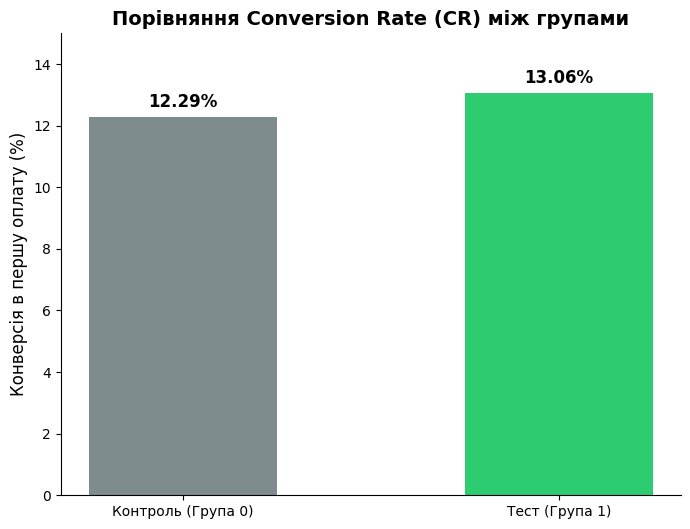

In [35]:
groups = ['Контроль (Група 0)', 'Тест (Група 1)']
crs = [12.29, 13.06] 

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(groups, crs, color=['#7f8c8d', '#2ecc71'], width=0.5)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f'{yval:.2f}%', 
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Конверсія в першу оплату (%)', fontsize=12)
ax.set_title('Порівняння Conversion Rate (CR) між групами', fontsize=14, fontweight='bold')
ax.set_ylim(0, 15) 

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()